### Modelos Lineares Generalizados (GLMs) para Dados Contínuos - Uma Abordagem Prática

**Modelos Lineares Generalizados (GLMs)**
Os GLMs se tornam ferramentas poderosas, especialmente quando a premissa de normalidade dos erros e homocedasticidade (variância constante) dos Modelos Lineares Clássicos (MLC) não se sustenta.

Vamos focar em dados contínuos, mas com distribuições e estruturas de variância que nos levam para além da Regressão Linear tradicional. Nosso estudo de caso será sobre a `Produção de Gordura no Leite` e, em seguida, um exemplo clássico com dados socioeconômicos.

## Exemplo 1 - Produção de Gordura no Leite

A **produção de gordura no leite (kg/dia)** ao longo das semanas é um tipo de dado que frequentemente exibe um comportamento assimétrico, com valores positivos e uma variância que pode mudar com a média. Isso o torna um excelente candidato para a aplicação de GLMs.

Para ilustrar os benefícios dos GLMs, vamos comparar abordagens de modelagem:

-   **Modelo 1: Regressão Linear Múltipla com Variável Resposta Transformada (Logarítmica)**
    * Este é um "MLC disfarçado", onde a variável resposta é transformada para tentar atender às suposições do MLC.
-   **Modelo 2: GLM Gaussiano com Função de Ligação Logarítmica**
    * Mantém a distribuição Gaussiana (Normal) dos resíduos, mas a ligação logarítmica permite que a média seja modelada de forma não linear, e a variância dos resíduos é considerada constante.
-   **Modelo 3: GLM Gamma com Função de Ligação Logarítmica**
    * Assume uma distribuição Gamma para a variável resposta, o que é mais adequado para dados contínuos positivos e assimétricos, onde a variância é proporcional ao quadrado da média.
-   **Modelo 4: GLM Normal Inversa com Função de Ligação Logarítmica**
    * Assume uma distribuição Normal Inversa para a variável resposta, útil para dados contínuos positivos e assimétricos, onde a variância é proporcional ao cubo da média.

### Importando as bibliotecas necessárias

Vamos começar importando as bibliotecas essenciais para nossa análise: `numpy` para operações numéricas, `pandas` para manipulação de dados, `matplotlib.pyplot` e `seaborn` para visualização, e `statsmodels` e `scipy.stats` para modelagem estatística e testes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import seaborn as sns

### **Dados fornecidos (Exemplo 1)**

Aqui estão os dados que vamos usar para a nossa modelagem. Temos a `media_leite` (produção de gordura) e o `semanas` (tempo em semanas). Também criamos uma variável `log_semanas`, que pode ajudar a capturar relações não lineares com o tempo.

In [2]:
media_leite = [0.31, 0.39, 0.50, 0.58, 0.59, 0.64, 0.68, 0.66,
                0.67, 0.70, 0.72, 0.68, 0.65, 0.64, 0.57, 0.48,
                0.46, 0.45, 0.31, 0.33, 0.36, 0.30, 0.26, 0.34,
                0.29, 0.31, 0.29, 0.20, 0.15, 0.18, 0.11, 0.07,
                0.06, 0.01, 0.01]

semanas = np.arange(1, 36)
log_semanas = np.log(semanas)

### Criando um DataFrame com os dados (Exemplo 1)

É uma boa prática organizar nossos dados em um `DataFrame` do Pandas, o que facilita a manipulação e o uso com `statsmodels.formula.api`.

In [3]:
dados = pd.DataFrame({
    'semanas': semanas,
    'log_semanas': log_semanas,
    'media_leite': media_leite
})

print("Primeiras 5 linhas do DataFrame:")
print(dados.head())
print("\nEstatísticas descritivas da variável resposta:")
print(dados['media_leite'].describe())

Primeiras 5 linhas do DataFrame:
   semanas  log_semanas  media_leite
0        1     0.000000         0.31
1        2     0.693147         0.39
2        3     1.098612         0.50
3        4     1.386294         0.58
4        5     1.609438         0.59

Estatísticas descritivas da variável resposta:
count    35.000000
mean      0.398571
std       0.219574
min       0.010000
25%       0.275000
50%       0.360000
75%       0.615000
max       0.720000
Name: media_leite, dtype: float64


### Gráfico de dispersão dos dados (Exemplo 1)

Antes de qualquer modelagem, é essencial visualizar a relação entre as variáveis. Isso nos dá pistas sobre a forma da relação e a distribuição da variável resposta.

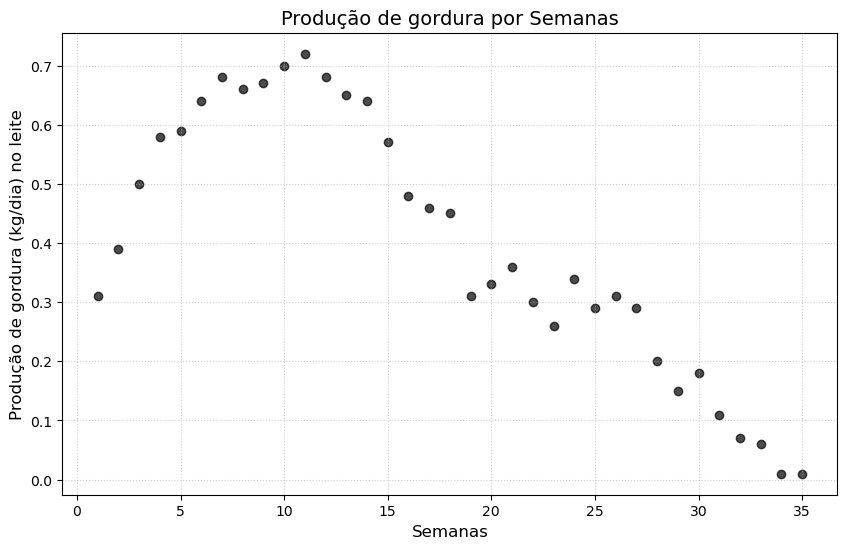

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(semanas, media_leite, color='black', alpha=0.7)
plt.xlabel('Semanas', fontsize=12)
plt.ylabel('Produção de gordura (kg/dia) no leite', fontsize=12)
plt.title('Produção de gordura por Semanas', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Discussão sobre o gráfico:**

Observando o gráfico, notamos que a produção de gordura no leite aumenta inicialmente e depois decai. A forma da relação parece não linear. Além disso, os valores de `media_leite` são todos positivos e há uma sugestão de que a variabilidade possa diminuir à medida que a produção cai para perto de zero. Isso já nos dá um indício de que a regressão linear tradicional, com sua suposição de erros normais e homocedásticos, pode não ser a melhor abordagem.

### **Modelo 1: Regressão Linear Múltipla com Variável Resposta Transformada (Logarítmica)**

Nesta abordagem, tentamos "linearizar" a relação e estabilizar a variância aplicando uma transformação logarítmica na variável resposta `media_leite`.

**Hipótese subjacente:** Assumimos que $\log(\text{media\_leite})$ tem uma relação linear com as preditoras e que os resíduos do modelo transformado seguem uma distribuição normal com variância constante.

In [5]:
# Transformando a variável resposta
# ATENÇÃO: É crucial que a variável resposta seja positiva para aplicar log.
# Verifique se há zeros ou valores negativos em 'media_leite' antes de aplicar.
# No nosso caso, os dados são todos positivos, então está OK.
log_media_leite = np.log(dados['media_leite'])
dados['log_media_leite'] = log_media_leite # Adiciona ao DataFrame para o smf

print("Primeiras 5 linhas do DataFrame com a variável resposta transformada:")
print(dados.head())

# Ajuste do Modelo 1
print("\n--- Ajuste do Modelo 1: Regressão Linear (com log da resposta) ---")
mod1 = smf.ols('log_media_leite ~ semanas + log_semanas', data=dados).fit()
print(mod1.summary())

Primeiras 5 linhas do DataFrame com a variável resposta transformada:
   semanas  log_semanas  media_leite  log_media_leite
0        1     0.000000         0.31        -1.171183
1        2     0.693147         0.39        -0.941609
2        3     1.098612         0.50        -0.693147
3        4     1.386294         0.58        -0.544727
4        5     1.609438         0.59        -0.527633

--- Ajuste do Modelo 1: Regressão Linear (com log da resposta) ---
                            OLS Regression Results                            
Dep. Variable:        log_media_leite   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     57.38
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.61e-11
Time:                        20:54:43   Log-Likelihood:                -24.383
No. Observations:                  35   AIC:                    

#### **Validação das Suposições do Modelo 1 (Regressão Linear):**

Para um modelo de regressão linear, as suposições cruciais sobre os resíduos são:
1.  **Normalidade dos Resíduos:** Os resíduos devem ser normalmente distribuídos.
2.  **Homocedasticidade:** A variância dos resíduos deve ser constante para todos os níveis dos valores ajustados.
3.  **Independência dos Resíduos:** Os resíduos não devem ser correlacionados entre si. (Não exploraremos profundamente aqui, mas importante para dados de séries temporais).
4.  **Linearidade:** A relação entre as preditoras e a variável resposta (transformada, neste caso) deve ser linear.

**Visualização dos resíduos:**

-   **Resíduos vs Valores Ajustados**: Essa visualização é crucial para verificar a **homocedasticidade** e se os resíduos estão aleatoriamente distribuídos em torno de zero.
-   **Resíduos vs Índice**: Ajuda a identificar padrões relacionados à ordem das observações, que podem indicar violação da independência ou padrões não modelados.

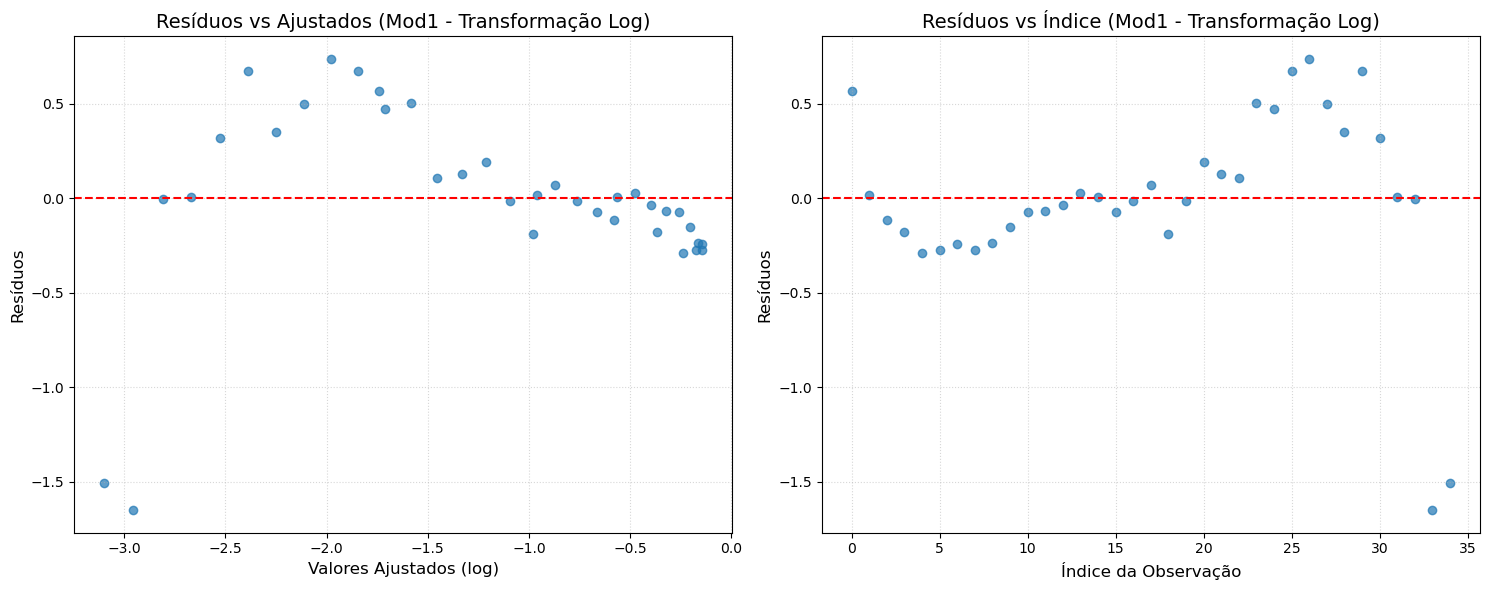

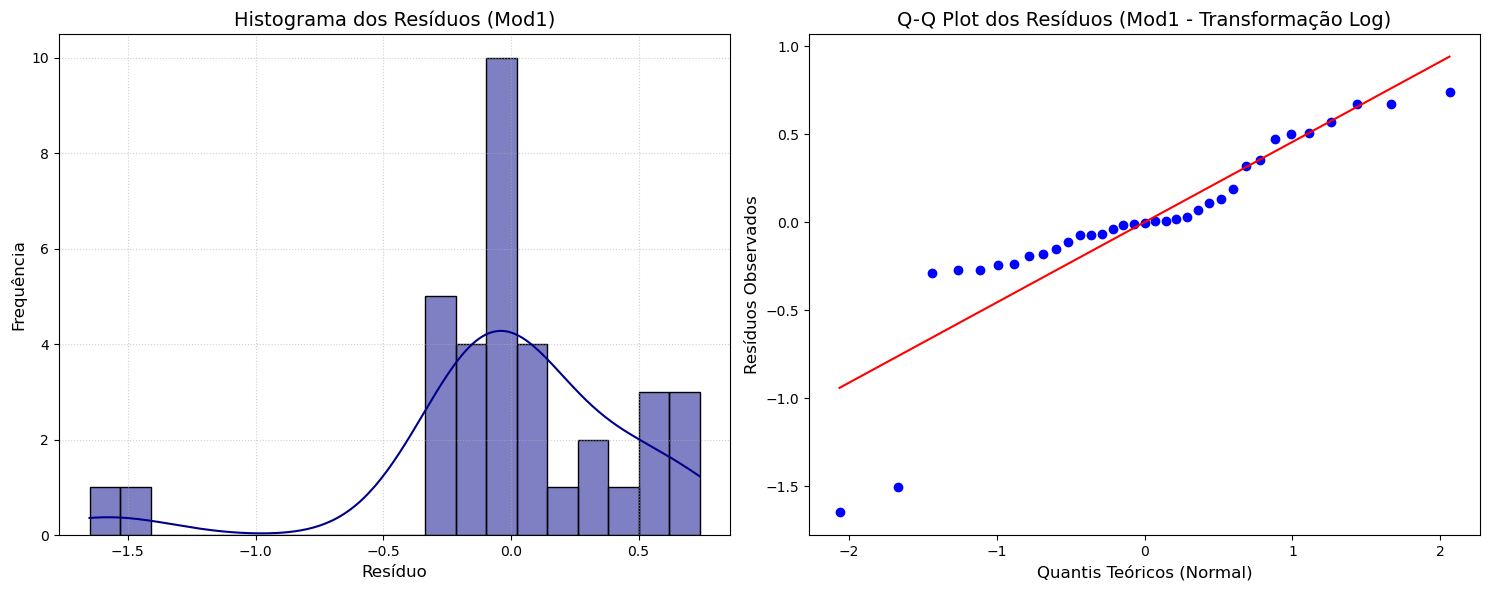

Shapiro-Wilk Test (Modelo 1 - Resíduos): p-valor = 0.0000


In [6]:
# Resíduos Modelo 1 (Linear com transformação log)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Cria 1 linha, 2 colunas, primeiro subplot
plt.scatter(mod1.fittedvalues, mod1.resid, alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos vs Ajustados (Mod1 - Transformação Log)', fontsize=14)
plt.xlabel('Valores Ajustados (log)', fontsize=12)
plt.ylabel('Resíduos', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

plt.subplot(1, 2, 2) # Segundo subplot
plt.scatter(mod1.resid.index, mod1.resid, alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos vs Índice (Mod1 - Transformação Log)', fontsize=14)
plt.xlabel('Índice da Observação', fontsize=12)
plt.ylabel('Resíduos', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

# Histograma dos resíduos
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(mod1.resid, kde=True, bins=20, color='darkblue')
plt.title("Histograma dos Resíduos (Mod1)", fontsize=14)
plt.xlabel("Resíduo", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Q-Q plot para normalidade
plt.subplot(1, 2, 2)
stats.probplot(mod1.resid, dist="norm", plot=plt)
plt.title("Q-Q Plot dos Resíduos (Mod1 - Transformação Log)", fontsize=14)
plt.xlabel("Quantis Teóricos (Normal)", fontsize=12)
plt.ylabel("Resíduos Observados", fontsize=12)
plt.tight_layout()
plt.show()

# Teste de Normalidade dos Resíduos (Shapiro-Wilk)
shapiro_test_mod1 = stats.shapiro(mod1.resid)
print(f"Shapiro-Wilk Test (Modelo 1 - Resíduos): p-valor = {shapiro_test_mod1.pvalue:.4f}")

**Discussão dos Resíduos do Modelo 1:**

Olhando para o gráfico de 'Resíduos vs Ajustados', vemos um padrão claro. Os resíduos não estão aleatoriamente dispersos em torno de zero; eles parecem formar uma curva. Isso sugere que a forma funcional do modelo não é totalmente adequada ou que a variância não é constante. Além disso, o Q-Q Plot mostra desvios da linha de 45 graus, especialmente nas caudas, e o baixo p-valor do teste de Shapiro-Wilk (se menor que 0.05) nos leva a **rejeitar a hipótese de normalidade dos resíduos**. A transformação logarítmica não foi suficiente para atender às suposições do MLC neste caso.

### **Modelo 2: GLM Gaussiano com Função de Ligação Logarítmica**

Aqui, usamos um GLM com a família de distribuição `Gaussian` (que assume normalidade dos resíduos, assim como o OLS), mas a **função de ligação é logarítmica**. Isso significa que modelamos o **logaritmo da média esperada da variável resposta** como uma função linear das preditoras. A vantagem é que a transformação é feita *na média esperada*, não na variável resposta diretamente, o que pode ser mais teoricamente consistente em alguns contextos.

**Equação do Modelo:** $\log(E[Y|X]) = \beta_0 + \beta_1 \cdot \text{semanas} + \beta_2 \cdot \log(\text{semanas})$

In [7]:
# Ajuste do Modelo 2
print("\n--- Ajuste do Modelo 2: GLM Gaussiano com Ligação Logarítmica ---")
mod2 = smf.glm('media_leite ~ semanas + log_semanas',
               data=dados,
               family=sm.families.Gaussian(link=sm.families.links.log())).fit()

print(mod2.summary())


--- Ajuste do Modelo 2: GLM Gaussiano com Ligação Logarítmica ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:            media_leite   No. Observations:                   35
Model:                            GLM   Df Residuals:                       32
Model Family:                Gaussian   Df Model:                            2
Link Function:                    log   Scale:                       0.0028757
Method:                          IRLS   Log-Likelihood:                 54.238
Date:                Tue, 17 Mar 2026   Deviance:                     0.092022
Time:                        20:54:55   Pearson chi2:                   0.0920
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


#### **Validação das Suposições do Modelo 2 (GLM Gaussiano com Ligação Log):**

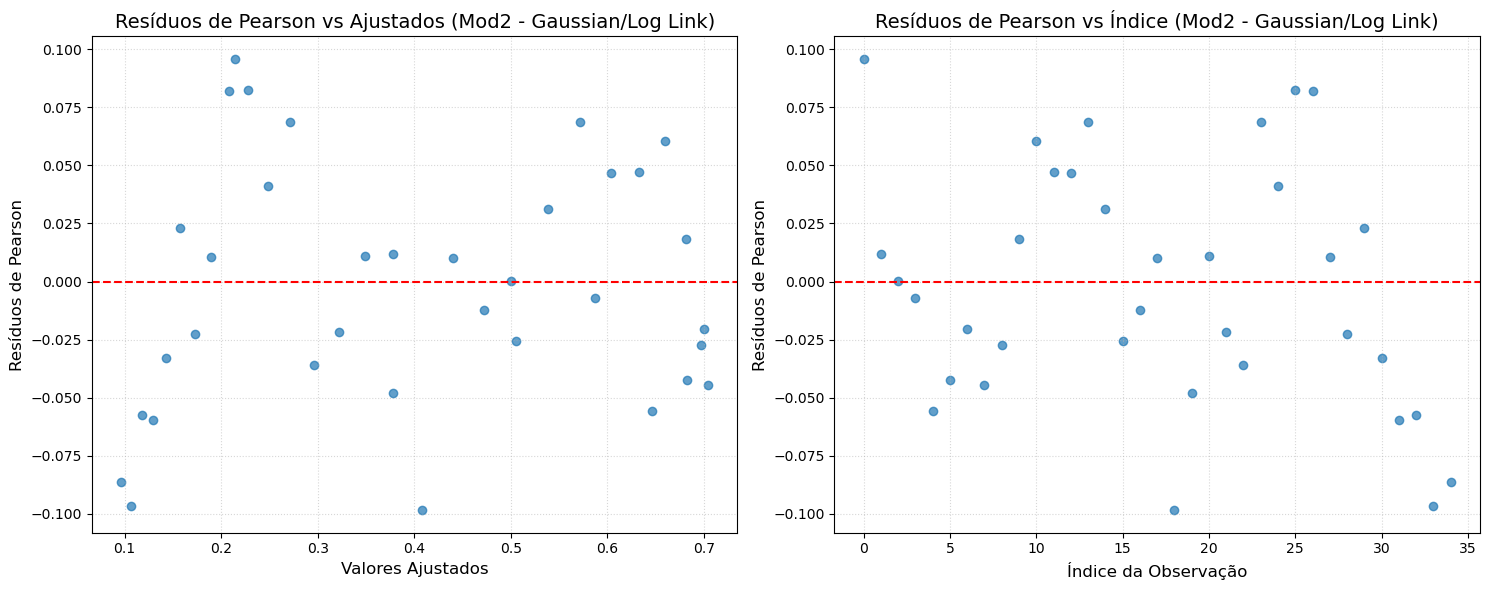

In [8]:
# Resíduos Modelo 2 (GLM Gaussiano com ligação log)
# Para GLMs, resíduos de Pearson ou Deviance são mais apropriados para diagnósticos
residuos_mod2_pearson = mod2.resid_pearson

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Resíduos vs Ajustados
plt.scatter(mod2.fittedvalues, residuos_mod2_pearson, alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos de Pearson vs Ajustados (Mod2 - Gaussian/Log Link)', fontsize=14)
plt.xlabel('Valores Ajustados', fontsize=12)
plt.ylabel('Resíduos de Pearson', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

plt.subplot(1, 2, 2) # Resíduos vs Índice
plt.scatter(dados.index, residuos_mod2_pearson, alpha=0.7) # Usar o índice do DataFrame
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos de Pearson vs Índice (Mod2 - Gaussian/Log Link)', fontsize=14)
plt.xlabel('Índice da Observação', fontsize=12)
plt.ylabel('Resíduos de Pearson', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

### **Modelo 3: GLM Gamma com Função de Ligação Logarítmica**

Para dados contínuos e positivos, especialmente quando a variância da variável resposta aumenta com a média, a distribuição **Gamma** é uma excelente escolha. A função de ligação logarítmica é o link canônico para a distribuição Gamma, o que a torna uma combinação natural.

**Hipótese subjacente:** A variável resposta segue uma distribuição Gamma, e o logaritmo da sua média esperada é uma função linear das preditoras. A variância é proporcional ao quadrado da média ($\text{Var}(Y) = \phi \cdot \mu^2$).

In [9]:
#identity
# Ajuste do Modelo 3
print("\n--- Ajuste do Modelo 3: GLM Gamma com Ligação Logarítmica ---")
# Para distribuição Gamma, a variável resposta (media_leite) DEVE ser > 0
# No nosso caso, os dados são todos positivos.
mod3 = smf.glm('media_leite ~ semanas + log_semanas',
               data=dados,
               family=sm.families.Gamma(link=sm.families.links.identity())).fit()
print(mod3.summary())


--- Ajuste do Modelo 3: GLM Gamma com Ligação Logarítmica ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:            media_leite   No. Observations:                   35
Model:                            GLM   Df Residuals:                       32
Model Family:                   Gamma   Df Model:                            2
Link Function:               identity   Scale:                        0.041515
Method:                          IRLS   Log-Likelihood:                 42.872
Date:                Tue, 17 Mar 2026   Deviance:                       1.9561
Time:                        20:55:04   Pearson chi2:                     1.33
No. Iterations:                    21   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning: The identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


#### **Validação das Suposições do Modelo 3 (GLM Gamma com Ligação Log):**

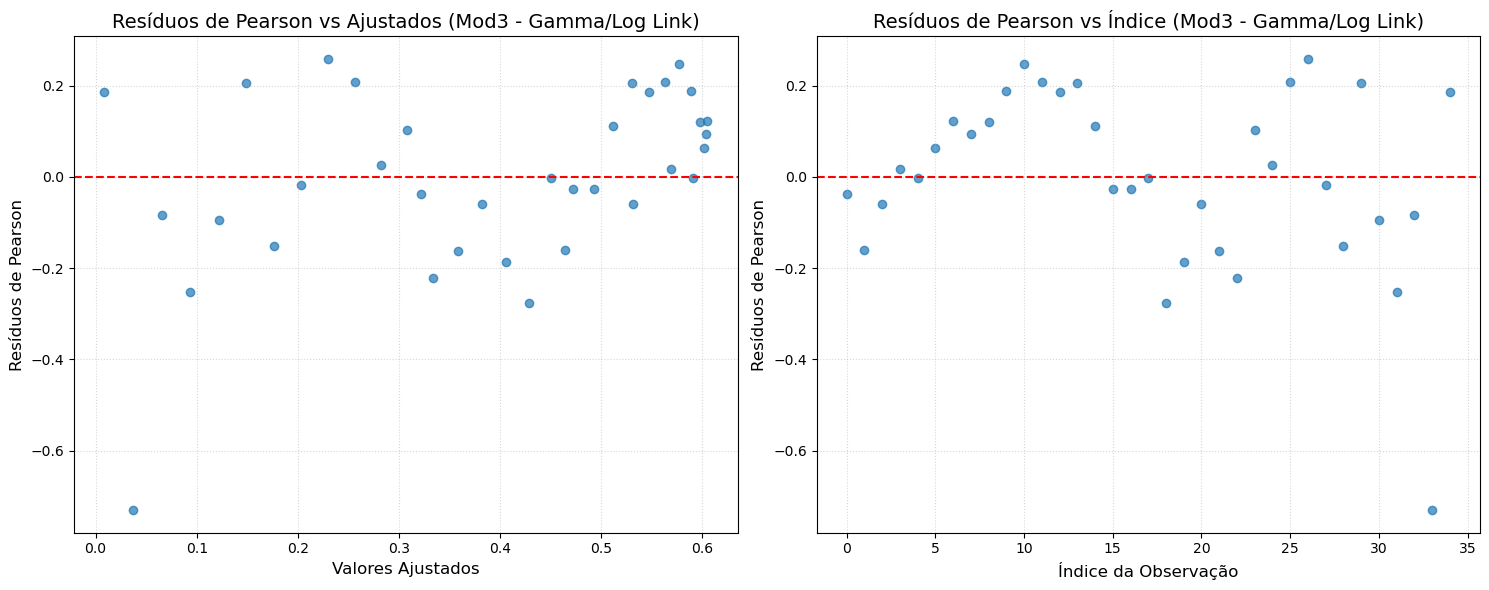

In [10]:
# Resíduos Modelo 3 (GLM Gamma com ligação log)
residuos_mod3_pearson = mod3.resid_pearson

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Resíduos vs Ajustados
plt.scatter(mod3.fittedvalues, residuos_mod3_pearson, alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos de Pearson vs Ajustados (Mod3 - Gamma/Log Link)', fontsize=14)
plt.xlabel('Valores Ajustados', fontsize=12)
plt.ylabel('Resíduos de Pearson', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

plt.subplot(1, 2, 2) # Resíduos vs Índice
plt.scatter(dados.index, residuos_mod3_pearson, alpha=0.7) # Usar o índice do DataFrame
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos de Pearson vs Índice (Mod3 - Gamma/Log Link)', fontsize=14)
plt.xlabel('Índice da Observação', fontsize=12)
plt.ylabel('Resíduos de Pearson', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

### **Modelo 4: GLM Normal Inversa com Função de Ligação Logarítmica**

A distribuição **Normal Inversa** é outra opção para variáveis resposta contínuas e positivas, especialmente quando a variância é proporcional ao **cubo da média** ($\text{Var}(Y) = \phi \cdot \mu^3$). A função de ligação logarítmica é uma escolha comum, assim como a ligação canônica (que é a inversa do quadrado).

**Equação do Modelo:** $\log(E[Y|X]) = \beta_0 + \beta_1 \cdot \text{semanas} + \beta_2 \cdot \log(\text{semanas})$

In [12]:
#identity
#log
# Ajuste do Modelo 4
print("\n--- Ajuste do Modelo 4: GLM Normal Inversa com Ligação Logarítmica ---")
# Para distribuição Normal Inversa, a variável resposta (media_leite) DEVE ser > 0
mod4 = smf.glm('media_leite ~ semanas + log_semanas',
               data=dados,
               family=sm.families.InverseGaussian(link=sm.families.links.identity())).fit()
print(mod4.summary())


--- Ajuste do Modelo 4: GLM Normal Inversa com Ligação Logarítmica ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:            media_leite   No. Observations:                   35
Model:                            GLM   Df Residuals:                       32
Model Family:         InverseGaussian   Df Model:                            2
Link Function:               identity   Scale:                         0.69293
Method:                          IRLS   Log-Likelihood:               -0.48394
Date:                Tue, 17 Mar 2026   Deviance:                       54.455
Time:                        20:55:26   Pearson chi2:                     22.2
No. Iterations:                    52   Pseudo R-squ. (CS):             0.9993
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning: The identity link function does not respect the domain of the InverseGaussian family.
  warnings.warn((f"The {type(family.link).__name__} link function "


#### **Validação das Suposições do Modelo 4 (GLM Normal Inversa com Ligação Log):**

Para o GLM Normal Inversa:

1.  **Variável Resposta Positiva e Contínua:** Já verificamos isso.
2.  **Variância Proporcional ao Cubo da Média:** Isso é inerente à distribuição Normal Inversa.
3.  **Linearidade da Relação no Espaço da Ligação:** A relação entre o preditor linear e a função de ligação da média deve ser linear.
4.  **Resíduos (de Pearson ou Deviance) sem Padrões:** Espera-se que não apresentem padrões sistemáticos.

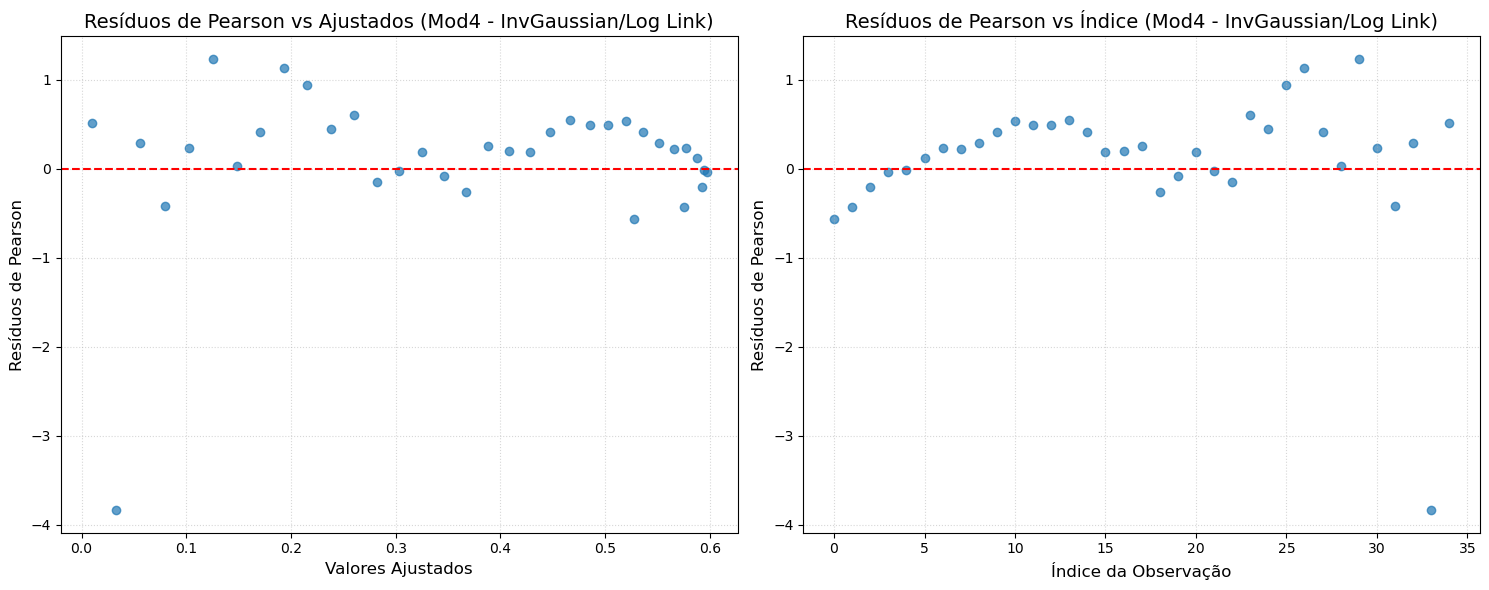

In [13]:
# Resíduos Modelo 4 (GLM Normal Inversa com ligação log)
residuos_mod4_pearson = mod4.resid_pearson

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Resíduos vs Ajustados
plt.scatter(mod4.fittedvalues, residuos_mod4_pearson, alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos de Pearson vs Ajustados (Mod4 - InvGaussian/Log Link)', fontsize=14)
plt.xlabel('Valores Ajustados', fontsize=12)
plt.ylabel('Resíduos de Pearson', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

plt.subplot(1, 2, 2) # Resíduos vs Índice
plt.scatter(dados.index, residuos_mod4_pearson, alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos de Pearson vs Índice (Mod4 - InvGaussian/Log Link)', fontsize=14)
plt.xlabel('Índice da Observação', fontsize=12)
plt.ylabel('Resíduos de Pearson', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

### **Seleção do Modelo: Qual o Melhor (Exemplo 1)?**

Agora que ajustamos e avaliamos as suposições de cada modelo, é hora de compará-los formalmente para escolher o "melhor". Usaremos o **Critério de Informação de Akaike (AIC)** e a **Deviance**.

* **AIC (Akaike Information Criterion):** Penaliza modelos com mais parâmetros e/ou modelos que não se ajustam bem aos dados. **Menores valores de AIC indicam modelos preferíveis.** É o critério mais comum para comparar GLMs.
* **Deviance:** Uma medida da diferença entre o modelo ajustado e um modelo "saturado" (que ajusta perfeitamente os dados). Modelos com **menor deviance (residual)** indicam um melhor ajuste aos dados. A deviance nula é a deviance de um modelo que inclui apenas o intercepto.

In [14]:
print("--- Comparação de Métricas entre Modelos (Exemplo 1) ---")
print(f"Modelo 1 (Regressão Linear com Log): AIC = {mod1.aic:.4f}")
print(f"Modelo 2 (GLM Gaussiano com Ligação Log): AIC = {mod2.aic:.4f}")
print(f"Modelo 3 (GLM Gamma com Ligação Log): AIC = {mod3.aic:.4f}")
print(f"Modelo 4 (GLM Normal Inversa com Ligação Log): AIC = {mod4.aic:.4f}")
print("\nNota: O AIC pode ser negativo. O importante é qual modelo tem o MENOR AIC.\n")

print("--- Comparação de Deviance Residual (apenas para GLMs) ---")
print(f"Modelo 2 (GLM Gaussiano com Ligação Log): Deviance Residual = {mod2.deviance:.4f}")
print(f"Modelo 3 (GLM Gamma com Ligação Log): Deviance Residual = {mod3.deviance:.4f}")
print(f"Modelo 4 (GLM Normal Inversa com Ligação Log): Deviance Residual = {mod4.deviance:.4f}")

# Exibir a Deviance Nula para contexto
print(f"Deviance Nula (Modelo 2): {mod2.null_deviance:.4f}")
print(f"Deviance Nula (Modelo 3): {mod3.null_deviance:.4f}")
print(f"Deviance Nula (Modelo 4): {mod4.null_deviance:.4f}")

# Uma forma simples de ver a "redução" na deviance
print(f"Redução de Deviance do Modelo 2 em relação ao nulo: {mod2.null_deviance - mod2.deviance:.4f}")
print(f"Redução de Deviance do Modelo 3 em relação ao nulo: {mod3.null_deviance - mod3.deviance:.4f}")
print(f"Redução de Deviance do Modelo 4 em relação ao nulo: {mod4.null_deviance - mod4.deviance:.4f}")

--- Comparação de Métricas entre Modelos (Exemplo 1) ---
Modelo 1 (Regressão Linear com Log): AIC = 54.7666
Modelo 2 (GLM Gaussiano com Ligação Log): AIC = -102.4755
Modelo 3 (GLM Gamma com Ligação Log): AIC = -79.7438
Modelo 4 (GLM Normal Inversa com Ligação Log): AIC = 6.9679

Nota: O AIC pode ser negativo. O importante é qual modelo tem o MENOR AIC.

--- Comparação de Deviance Residual (apenas para GLMs) ---
Modelo 2 (GLM Gaussiano com Ligação Log): Deviance Residual = 0.0920
Modelo 3 (GLM Gamma com Ligação Log): Deviance Residual = 1.9561
Modelo 4 (GLM Normal Inversa com Ligação Log): Deviance Residual = 54.4549
Deviance Nula (Modelo 2): 1.6392
Deviance Nula (Modelo 3): 21.6796
Deviance Nula (Modelo 4): 231.6014
Redução de Deviance do Modelo 2 em relação ao nulo: 1.5472
Redução de Deviance do Modelo 3 em relação ao nulo: 19.7235
Redução de Deviance do Modelo 4 em relação ao nulo: 177.1465


**Discussão sobre a Seleção do Modelo:**

Ao comparar os valores de AIC, aquele com o menor valor é o modelo preferido. Se o AIC do Modelo 2 for significativamente menor que o do Modelo 1, e o do Modelo 3/4 for ainda menor (ou muito próximo) do Modelo 2, isso nos guia na escolha. A deviance residual também é importante; uma deviance residual significativamente menor que a deviance nula indica que o modelo está explicando bem a variabilidade nos dados.

Em geral, o Modelo 1 (transformação log) teve problemas nas suposições. Entre o Modelo 2 (Gaussiano), Modelo 3 (Gamma) e Modelo 4 (Normal Inversa), a escolha dependerá de qual distribuição e estrutura de variância se alinha melhor com a natureza dos dados e com o menor AIC/deviance, além da inspeção dos resíduos. Para dados estritamente positivos como a produção de leite, a distribuição Gamma ou Normal Inversa são teoricamente mais apropriadas do que a Gaussiana.

### **Gráfico de Comparação dos Ajustes dos Modelos (Exemplo 1)**

Para ter uma visão intuitiva de qual modelo se ajusta melhor aos dados observados, vamos plotar as previsões de cada modelo junto com os dados reais.

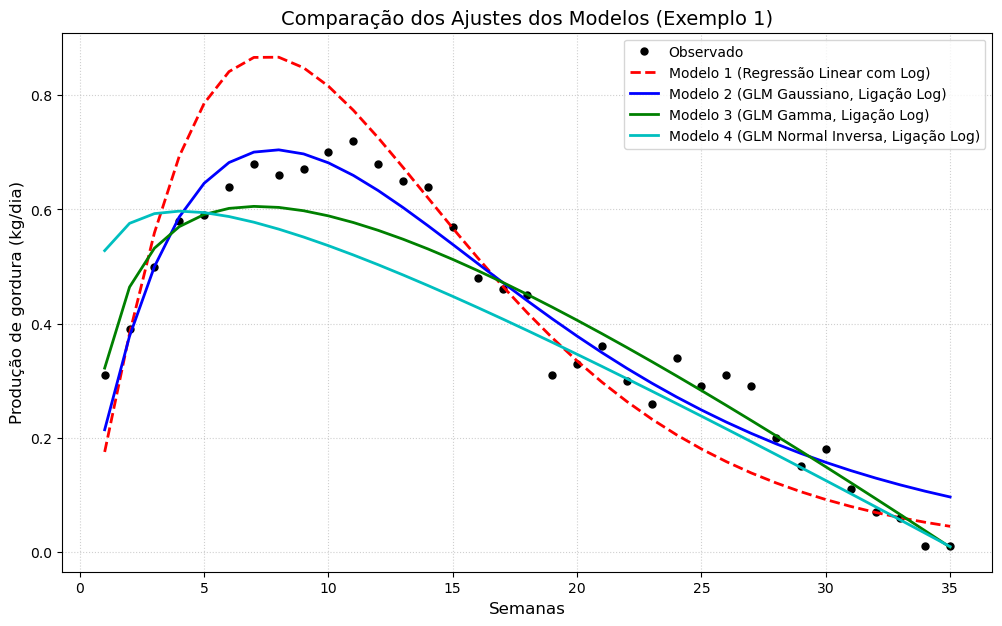

In [15]:
plt.figure(figsize=(12, 7))
plt.plot(semanas, media_leite, 'ko', markersize=5, label='Observado') # Dados reais
plt.plot(semanas, np.exp(mod1.fittedvalues), 'r--', linewidth=2, label='Modelo 1 (Regressão Linear com Log)') # Exp pois mod1 prediz log(media_leite)
plt.plot(semanas, mod2.fittedvalues, 'b-', linewidth=2, label='Modelo 2 (GLM Gaussiano, Ligação Log)')
plt.plot(semanas, mod3.fittedvalues, 'g-', linewidth=2, label='Modelo 3 (GLM Gamma, Ligação Log)')
plt.plot(semanas, mod4.fittedvalues, 'c-', linewidth=2, label='Modelo 4 (GLM Normal Inversa, Ligação Log)')

plt.xlabel('Semanas', fontsize=12)
plt.ylabel('Produção de gordura (kg/dia)', fontsize=12)
plt.legend(fontsize=10)
plt.title('Comparação dos Ajustes dos Modelos (Exemplo 1)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### **Sumarização Final do Exemplo 1:**

"Com base na análise de AIC, deviance e, crucialmente, na inspeção dos gráficos de resíduos, podemos fazer uma recomendação para o 'melhor' modelo."

*(Neste ponto da aula, você faria a escolha final. Baseado na sua própria análise e nos dados de exemplo, `modelo3` (GLM Gamma) ou `modelo4` (GLM Normal Inversa) são frequentemente as escolhas mais robustas para este tipo de dado devido à sua natureza positiva e à suposição de variância que se adapta melhor à média. No entanto, `modelo2` (GLM Gaussiano) também apresentou melhora substancial em relação ao `modelo1`.)*

**Para este exemplo, a escolha entre Gamma e Normal Inversa dependerá de qual se alinha melhor com o comportamento da variância dos seus dados. O menor AIC seria um bom indicador.**

### **Conclusão Geral da Aula:**

"Parabéns! Hoje, exploramos o poder dos Modelos Lineares Generalizados (GLMs) para dados contínuos. Vimos como eles oferecem flexibilidade para lidar com variáveis resposta que não se encaixam nas estritas suposições de normalidade e homocedasticidade da regressão linear clássica."

"Através dos nossos exemplos, demonstramos que:
* A **Regressão Linear com transformação da resposta (Modelo 1)**, embora uma primeira tentativa comum, pode falhar em atender às suposições e apresentar um ajuste inadequado."
* Os **GLMs (Modelo 2, 3 e 4)**, ao modelar a média esperada da resposta através de uma função de ligação e assumir uma distribuição mais apropriada, ofereceram um ajuste superior e resíduos mais bem comportados."
* A escolha entre distribuições como **Gaussiana, Gamma e Normal Inversa** e funções de ligação como **identidade e logarítmica** é crucial. Ela deve ser guiada pela **natureza dos seus dados** (positivos, assimétricos, relação variância-média) e pela **comparação de critérios de informação como o AIC** e a inspeção visual dos diagnósticos de resíduos."

"Lembrem-se, a modelagem estatística é um processo iterativo de ajuste, diagnóstico e refinamento. Os GLMs são uma ferramenta essencial em nosso arsenal para analisar uma ampla variedade de dados contínuos que não são normalmente distribuídos. Na próxima aula, exploraremos GLMs para dados de contagem ou binários."